# Aspirin Hydrolysis Curve Fits

The data is from  Edwards, L.J., "The hydrolysis of aspirin." *Trans. Faraday Soc.*, **1950**, *46*, 723-735. https://doi.org/10.1039/TF9504600723

## Load Data

The data table from the above paper was made into a csv file (`Edwards1950.csv`). The file contains pH and k_obs values. It is read into a dataframe with the pH va;ues as the index series.  Then a $\log{(K_{obs})}$ series is created and a series for $[H^+]$

In [2]:
#!pip install uncertainties
#!pip install lmfit

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import linregress
from scipy.optimize import curve_fit

import uncertainties as un               # tool set for handling uncertainties
from uncertainties import unumpy as unp  # a replacement for numpy 

import lmfit     

!mkdir plots

################################################################################
### Set global variables. Set flag accordingly
################################################################################

#github = True  
github = False  

if github:
    data_path = "https://raw.githubusercontent.com/blinkletter/4410PythonNotebooks/main/Class_10/data/"
    image_path = "https://raw.githubusercontent.com/blinkletter/4410PythonNotebooks/main/Class_10/images/"
    github_data_location = "https://raw.githubusercontent.com/blinkletter/LFER-QSAR/main/data/"
    github_styles_location = "https://raw.githubusercontent.com/blinkletter/LFER-QSAR/main/styles/"
else:
    data_path = "data/"
    image_path = "images/"
    github_data_location = "/Users/blink/github/LFER-QSAR/data/"
    github_styles_location = "../../styles/"

    

################################################################################
### Read data set. The fields are separated by commas; comments are enabled  
################################################################################

df = pd.read_csv(data_path + "Edwards1950.csv", 
                 delimiter = ",", 
                 skipinitialspace=True, 
                 index_col="pH", 
                 comment = "#") 

################################################################################
### Process data  
################################################################################

df["logk"] = np.log10(df["k_obs"])        # get log(K) from K
df["H"]=10**(-df.index)                   # get [H] from pH
df.sort_values(by=['pH'], inplace=True)   # one value was out of order, sort to fix.

display(df.head())

len(df)

mkdir: plots: File exists


,k_obs,logk,H
pH,,,
0.53,0.5780,-0.238072,0.295121
1.00,0.1900,-0.721246,0.100000
1.33,0.0835,-1.078314,0.046774
1.80,0.0450,-1.346787,0.015849
2.48,0.0267,-1.573489,0.003311


28

## Plot the Data

Below is code that will plot the log-log plot for the pH-rate profile. We will plot $\log{k_{obs}}$ vs. $pH$

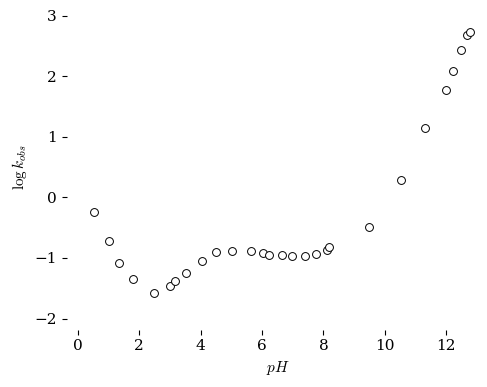

In [3]:
################################################################################
### Choose x and y for plot
################################################################################

x = df.index             # pH values are in the index of the dataframe
y = np.array(df["logk"]) # log(k_obs) values

################################################################################
### Setup a figure with two plots side-by-side and choose a stylesheet
################################################################################

# reset the default style settings for matplotlib so we always start from the same stylesheet
plt.rcdefaults()  # reset the default style settings for matplotlib so we always start from the same stylesheet

# Choose a style sheet for the plot. The stylesheets are in the "styles" folder of the GitHub repository.
plt.style.use(github_styles_location + "tufte.mplstyle")        
#plt.style.use(github_styles_location + "S2_classic2.mplstyle")

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,4))  

################################################################################
### Plot the data    
################################################################################

ax.scatter(x, y, 
           marker = "o", s=32, 
           c="white", edgecolor = "black",
           linewidth = 0.7, label=r"$\log{k_{obs}}$", zorder=3)
   
################################################################################
### Set labels and scale 
################################################################################

ax.spines["left"].set_position(("outward", 8))
ax.spines["bottom"].set_position(("outward", 8))
ax.set(ylabel=r"$\log{k_{obs}}$", 
       xlabel=r"$pH$",
       xlim=[0,13],                  
       ylim=[-2,3],     
      )
#ax.margins(x=.07, y=.07, tight=True)      # add 7% empty space around outside of plot area   

################################################################################
### Output the final plot 
################################################################################

fig.savefig("plots/01_plot.pdf")   # use this to save the figure in PDF format
plt.show()                            # output the plot to the screen



First we define the components of the pH-rate profile

## Defining Functions

The functions below describe each mechanism in the model. And then a final model is created that calculates the sum of the rate constant contributions from each component to give the total observed rate constant, $k_{obs}$. 

In [5]:
################################################################################
### Functions that define each component's rate constant
################################################################################

def genbase(pH, pKa=3.55, k= 0.117): # fit the intramolecular general base-catalyzed rate
    Ka = 10**(-pKa)
    H = 10**(-pH)
    frac_base = Ka/(H + Ka)
    rateconst = k * frac_base
    return rateconst

def genacid(pH, pKa=3.55, k=0.01):   # fit the water rate (kinetically indistiguishable from GA)
    Ka = 10**(-pKa)
    H = 10**(-pH)
    frac_acid = H/(Ka + H) # The fraction in the protonated, neutral form is H/(Ka + H)
    rateconst = k * frac_acid
    return rateconst

def specificacid(pH, pKa=3.55, k= 1.9):   # fit the specific acid-catalyzed rate 
    Ka = 10**(-pKa)
    H = 10**(-pH)
    frac_acid = H/(Ka + H) # The fraction in the protonated, neutral form is H/(Ka + H)
    rateconst = (H*k) * frac_acid
    return rateconst    
    
def specificbase(pH, k=7500, pKa=3.55, pKW=14):  # fit the specific base-catalyzed rate
    H = 10**(-pH)
    KW = 10**(-pKW)
    OH = KW / H
    Ka = 10**(-pKa)
    frac_base = Ka/(H + Ka)
    rateconst = (OH*k*frac_base)
    return rateconst   

################################################################################
### Function that defines the model - used in curve fit
################################################################################

def aspirin_model(pH, ka = 1.9, kb=0.01, kc = 0.12, kd = 7500, pKa = 3.55, pKW = 14):    
    """
    aspirin_model(pH, ka, kb, kc, kd, pKa, pKW) - model for the pH-rate profile of aspirin hydrolysis
    pH is an array of pH values
    returns an array of k_obs values
    """
    H = 10**(-pH)
    k_obs = specificacid(pH, pKa, ka) + genacid(pH, pKa, kb) + genbase(pH, pKa, kc) + specificbase(pH, kd, pKa, pKW)
    return np.log10(k_obs)

def aspirin_model2(pH, ka = 1.88, kb=0.01, kc = 0.119, kd = 7970, pKa = 3.55, pKW = 14):    
    """
    model(x, ka, kb, kc, kd, Ka2, Ka1)
    pH is an array of pH values
    returns an array of log(k_obs) values
    """
    H = 10**(-pH)
    Ka1 = 10**(-pKa)
    KW = 10**(-pKW)
    k_obs = (ka*(H) + kb + kc*(Ka1/H) + kd*(Ka1/H)*(KW/H))/(1 + (Ka1/H))
    return(np.log10(k_obs))

def aspirin_model3(pH, ka = 1.88, kb=0.01, kc = 0.119, kd = 7970, pKa = 3.55, pKW = 14):    
    """
    model(x, ka, kb, kc, kd, Ka2, Ka1)
    pH is an array of pH values
    returns an array of log(k_obs) values
    """
    H = 10**(-pH)
    Ka1 = 10**(-pKa)
    KW = 10**(-pKW)
    k_obs = (ka*H**3 + kb*H**2 + kc*Ka1*H + kd*Ka1*KW)/(H**2 + (Ka1*H))
    return(np.log10(k_obs))



### Test the Model

Below I plot the data against values that are known from the Edwards paper. The plot generated from the functions matches the data. 

Always test early and often. If you make any improvements to the code, test again. Test, test, test.

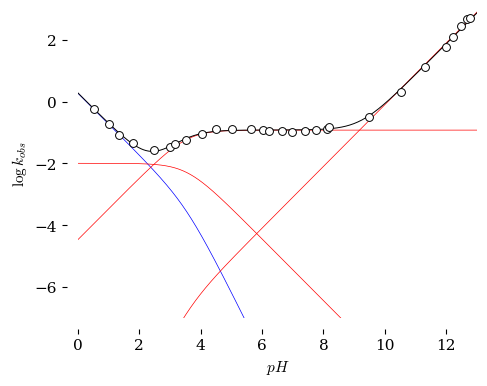

In [6]:
################################################################################
### Choose x and y for plot
################################################################################

x = df.index             # pH values are in the index of the dataframe
y = np.array(df["logk"]) # log(k_obs) values

x_fit = np.linspace(0, 13, 500)  # create a smooth x array for plotting the model
y_fit = aspirin_model(x_fit)     # No parameters given. Default values are used for the model. 

################################################################################
### Setup a figure with two plots side-by-side and choose a stylesheet
################################################################################

# reset the default style settings for matplotlib so we always start from the same stylesheet
plt.rcParams.update(plt.rcParamsDefault)

# Choose a style sheet for the plot. The stylesheets are in the "styles" folder of the GitHub repository.
plt.style.use(github_styles_location + "tufte.mplstyle")        
#plt.style.use(github_styles_location + "S2_classic2.mplstyle")

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,4))  

################################################################################
### Plot the data    
################################################################################

ax.scatter(x, y, 
           marker = "o", s=32, 
           c="white", edgecolor = "black",
           linewidth = 0.7, label=r"$\log{k_{obs}}$", zorder=3)
   

################################################################################
### Plot the results of known values in black    
################################################################################

ax.plot(x_fit, y_fit, 
        color="black", linewidth=0.7, zorder=2)

################################################################################
### Plot the results of known values for components in red    
################################################################################

y_fit = np.log10(specificacid(x_fit, k=1.88))
ax.plot(x_fit, y_fit,
        color="blue", linewidth=0.5, zorder=1)

y_fit = np.log10(genacid(x_fit, pKa=3.55, k=0.01))
ax.plot(x_fit, y_fit,
        color="red", linewidth=0.5, zorder=1)

y_fit = np.log10(genbase(x_fit, pKa=3.55, k=0.119))
ax.plot(x_fit, y_fit,
        color="red", linewidth=0.5, zorder=1)

y_fit = np.log10(specificbase(x_fit, k=7970, pKa=3.55, pKW=14))
ax.plot(x_fit, y_fit,
        color="red", linewidth=0.5, zorder=1)
 
################################################################################
### Set labels and scale 
################################################################################

ax.spines["left"].set_position(("outward", 8))
ax.spines["bottom"].set_position(("outward", 8))

ax.set(ylabel=r"$\log{k_{obs}}$", 
       xlabel=r"$pH$",
       xlim=[0,13],                  
       ylim=[-7,3],     
      )
#ax.margins(x=.07, y=.07, tight=True)      # add 7% empty space around outside of plot area   

################################################################################
### Output the final plot 
################################################################################

fig.savefig("plots/02_plot_test.pdf")   # use this to save the figure in PDF format
plt.show()                            # output the plot to the screen

### Perform a Curve Fit

Using the model, let us fit it against the data using LMFit

In [7]:
from lmfit import Model

x = df.index             # pH values are in the index of the dataframe
y = np.array(df["logk"]) # log(k_obs) values

gmodel = Model(aspirin_model, nan_policy='omit')
params = gmodel.make_params(                    # initial values and constraints
                        ka = dict(value = 0.2, min = 1E-15, max = 100),
                        kb = dict(value = 0.015, min = 1E-15, max = 100),
                        kc = dict(value = 0.15, min = 1E-15, max = 100),
                        kd = dict(value = 10000, min = 1, max = 100000),
                        pKa = dict(value = 4., min = 1, max = 10),
                        pKW = dict(value = 14.0, vary = False)
                        )    
# note: in fitting a model, all parameters must be named in the model function, 
# even if they are not varied. The parameters that are not varied can be set 
# to a fixed value in the make_params() call. The x variable must also be named 
# in the model function.
result = gmodel.fit(y, params, pH=x)

print(result.fit_report())

[[Model]]
    Model(aspirin_model)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 31
    # data points      = 28
    # variables        = 5
    chi-square         = 0.09112114
    reduced chi-square = 0.00396179
    Akaike info crit   = -150.377559
    Bayesian info crit = -143.716536
    R-squared          = 0.99816138
[[Variables]]
    ka:   1.74957681 +/- 0.17394139 (9.94%) (init = 0.2)
    kb:   0.01423640 +/- 0.00449415 (31.57%) (init = 0.015)
    kc:   0.11987207 +/- 0.00543029 (4.53%) (init = 0.15)
    kd:   7555.77838 +/- 405.072316 (5.36%) (init = 10000)
    pKa:  3.65408835 +/- 0.12326832 (3.37%) (init = 4)
    pKW:  14 (fixed)
[[Correlations]] (unreported correlations are < 0.100)
    C(kb, pKa) = +0.7344
    C(ka, kb)  = -0.5295
    C(kc, pKa) = +0.3992
    C(ka, pKa) = -0.3540
    C(kb, kc)  = +0.1187


## Calculate Line Fit and Uncertainty (Confidence Interval and Prediction Interval)

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t

###############################################################################
# Generate smooth curve
###############################################################################

x_fit = np.linspace(0, 13, 500)  # create a smooth x array for plotting the model

# Best-fit curve
y_fit = result.eval(pH=x_fit)

# Confidence intervals
ci = result.eval_uncertainty(pH=x_fit, sigma=0.95)  # 95% confidence interval. For 95% confidence interval, use sigma=1.96 for large sample sizes, but lmfit can use sigma=0.95 for 95% CI.

ci_upper = y_fit + ci
ci_lower = y_fit - ci

# Prediction intervals
se = result.eval_uncertainty(pH=x_fit, sigma=1)  # standard error of the fit
mse = result.redchi  # reduced chi-squared value from the fit (mean squared error)
se_pred = np.sqrt(se**2 + mse)

dof = result.ndata - result.nvarys # degrees of freedom = number of data points - number of fitted parameters
tval = t.ppf(0.975,dof)  # two-tailed t-value for 95% confidence interval
pi = tval * se_pred

pi_lower = y_fit - pi
pi_upper = y_fit + pi

## Plot the line fit and confidence intervals

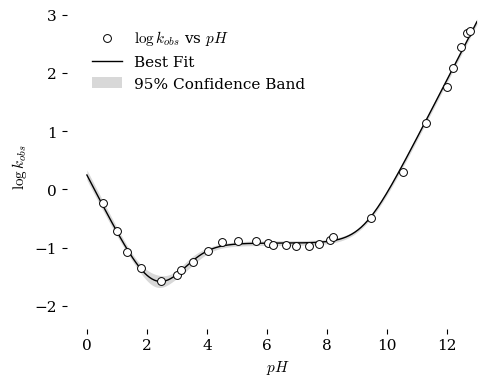

In [9]:
###############################################################################
# Plot
###############################################################################

################################################################################
### Setup a figure  and choose a stylesheet   
################################################################################
plt.rcdefaults()
plt.style.use(github_styles_location + "tufte.mplstyle")        
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,4))  

ax.scatter(x, y, 
           marker = "o", s=32, 
           c="white", edgecolor = "black",
           linewidth = 0.7, label=r"$\log{k_{obs}}$ vs $pH$", zorder=4)



ax.plot(
    x_fit,
    y_fit,
    color="black",
    lw=1,
    label="Best Fit",
    zorder = 3
)

ax.fill_between(
    x_fit,
    ci_lower,
    ci_upper,
    linewidth = 0,
    facecolor="gray", # darkgray
    edgecolor = "gray", # dimgray
#    facecolor="lightskyblue",
#    edgecolor = "dodgerblue",
    alpha=0.30,
    label="95% Confidence Band",
    zorder = 2

)

if False:  # turn off prediction band for now
    ax.fill_between(
        x_fit,
        pi_lower,
        pi_upper,
    #    ls = "None",
        linewidth = 0.5,
        facecolor="white",  #gainsboro
        edgecolor = "darkgray",
    #    facecolor="honeydew",
    #    edgecolor = "lightgreen",
    #    alpha=0.30,
        label="95% Prediction Band",
        zorder = 1
    )

ax.spines["left"].set_position(("outward", 8))
ax.spines["bottom"].set_position(("outward", 8))

ax.set(ylabel=r"$\log{k_{obs}}$", 
       xlabel=r"$pH$",
          xlim=[-0.3,13],                  
          ylim=[-2.2,3]
      )


plt.legend()
plt.tight_layout()
fig.savefig("plots/03_plot_LMFit_CI_PI.pdf")   # use this to save the figure in PDF format

plt.show()

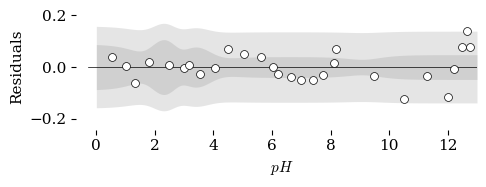

In [10]:
################################################################################
### Setup a figure  and choose a stylesheet   
################################################################################
plt.rcdefaults()
plt.style.use(github_styles_location + "tufte.mplstyle")        
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,2))  

################################################################################
### Plot the data and the line fit.   
################################################################################

ax.axhline(0, linewidth = 0.5)

ax.scatter(x, y - result.eval(pH=x), 
           marker = "o", s=32, 
           color="white", edgecolor = "black",
           linewidth = 0.5, zorder=3)

################################################################################
### Set labels and scale 
################################################################################
ax.spines["left"].set_position(("outward", 8))
ax.spines["bottom"].set_position(("outward", 8))

ax.set(ylabel=r"Residuals", 
       xlabel=r"$pH$",
          xlim=[-0.3,13],                  
          ylim=[-0.2,0.2]
      )

#ax.margins(x=.07, y=.07, tight=True)  # add 7% empty space around outside of plot area   


# upper and lower bounds of uncertain kobs as float values

################################################################################
### Create Confidence band upper and lower bounds
################################################################################

ax.fill_between(x_fit, -ci, ci, 
                   color="gray", alpha=0.2, zorder = 0,
                   linewidth=0, label="confidence interval")

# prediction inteerval bounds
ax.fill_between(x_fit, -pi, pi,
                   color="gray", alpha=0.20, zorder = 0,
                   linewidth=0, label="prediction interval")

#############################
### Output the final plot ###
#############################

fig.savefig("plots/06_plot_pH3_LMFit_residuals.pdf")   # use this to save the figure in PDF format
plt.show()                 # output the combined plot plots


## Bootstraping

Bootstrapping is considered to be better at determining the confidence interval for complicated nonlinear functions. A bootstrap interval is a confidence interval determined by taking a set of 5000 random samples from the data set, with replacement. That means that we take 28 random samples from the data set of 28 numbers. We pick from the whole data set every time so it is likely that there will be duplicated and omitted data points in all the resamples. We can create thousnads of random data sets from the original. Then we can curve fit these 5000 data sets and obtain a set of 5000 curve fit parameters. The values at the 2.5 and 97.5% quantiles will represent the edges of the 95% confidence interval.

We can also calulate the values of the model using each parameter set and plot 5000 line fits. Again, the values at the 2.5 and 97.5% quantiles at each point of the x-axis will represent the confidence band along the curve fit.

**for more about bootstrapping see...**

https://en.wikipedia.org/wiki/Bootstrapping_(statistics)

Hesterberg, T. C. "What Teachers Should Know About the Bootstrap: Resampling in the Undergraduate Statistics Curriculum." *The American Statistician*, **2015**, *69*, 371–386. https://doi.org/10.1080/00031305.2015.1089789. Subscription access. Free access available at https://pmc.ncbi.nlm.nih.gov/articles/PMC4784504/

Joseph, Trist’n. “Bootstrapping Statistics. What It Is and Why It’s Used.” Toward Data Science, 17 June 2020, https://medium.com/data-science/bootstrapping-statistics-what-it-is-and-why-its-used-e2fa29577307. Accessed 9 Sept. 2026.

### BCA Bootstrap

The bias-corrected and accelerated (BCA) is a method that uses Baysian statistics to correct for bias and skew in the data set. It is the most recommended method for complicated models. There are many ways to perform a boostrap. Always provide the code when doing statistics so that others can inspect your method and not just assume you did things the correct way.

The accelleration is determined using *Jackknife* resampling where 28 data sets of 27 points each are creayted by deleting a single data point from data set. For more about jackknife resampling seee https://en.wikipedia.org/wiki/Jackknife_resampling

**For more about the BCA algorithm used here, see...**

Efron, B., Narasimhan, B. "The Automatic Construction of Bootstrap Confidence Intervals." *J. Comp. Graph. Stat.*, **2020** *29*, 608–619. https://doi.org/10.1080/10618600.2020.1714633. Subscription access. Free access available at https://pmc.ncbi.nlm.nih.gov/articles/PMC7958418/

### The Code

Below is the code to perfrom the bootstrap and collect all the best fit curves from each fit.



In [11]:
import numpy as np
import pandas as pd

from scipy.stats import fit, norm

def bca_bootstrap(model, result, x, nboot=5000, alpha=0.05, seed=123,):

    """
    BCa bootstrap confidence intervals
    for LMFit parameters.

    Parameters
    ----------
    model : lmfit.Model - the model used to fit the data
    result : lmfit.ModelResult - the original result of fitting the model to the data
    x : ndarray of original x values (pH)
    nboot : int - number of bootstrap samples
    alpha : float - value of 0.05 means 95% CI

    Returns
    -------
    DataFrame of values for each parameter, including the best-fit value, lower and upper bounds of the confidence interval, bias correction, and acceleration.
    """

    rng = np.random.default_rng(seed)                  # initialize the random number generator

    residuals = (result.data - result.best_fit)        # residuals of the fit
    param_names = result.var_names                     # list of parameter names
    theta_hat = {p: result.params[p].value for p in param_names} # dictionary of best-fit parameter values

    # ----------------------------------------------------------
    # Bootstrap
    # ----------------------------------------------------------
    
    curve_samples = []                                 # create a list to hold the bootstrap samples for the curve
    boot = {p: [] for p in param_names}                # create a dictionary to hold the bootstrap samples for each parameter

    successes = 0                                      # count the number of successful fits

    for i in range(nboot):                             # repeat for the number of bootstrap samples
        try:                                           # attempt to fit the model to a bootstrap sample. If the fit fails, skip this sample and continue to the next one.
            # This algorithm resamples the list of residuals with replacement, adds the resampled residuals to 
            # the best-fit values, and then fits the model to the new data. The best-fit parameters for each 
            # bootstrap sample are stored in a dictionary.
            resampled = rng.choice(residuals, size=len(residuals), replace=True,)  # resample the residuals with replacement
            y_boot = (result.best_fit + resampled)     # add the resampled residuals to the best-fit values to create a new y array for the bootstrap sample

            fit = model.fit(y_boot, result.params.copy(), pH=x,) # fit the model to the bootstrap sample. result.params.copy() is used to provide the initial parameter values for the fit.

            for p in param_names:                      # append the best fit parameters for this bootstrap sample to each list in the dictionary
                boot[p].append(fit.params[p].value)

            curve = fit.eval(pH=x_fit)                 # evaluate the fitted curve for the bootstrap sample
            curve_samples.append(curve)                # append the fitted curve for the bootstrap sample to the list of curve samples

            successes += 1                             # increment the count of successful fits
        except Exception:                              # if the fit fails, just skip this bootstrap sample and continue to the next one
            pass

    print(
        f"Successful fits: "
        f"{successes}/{nboot}"
    )

    # ----------------------------------------------------------
    # Jackknife for acceleration
    # ----------------------------------------------------------

    jackknife = {}                                    # create a dictionary to hold the jackknife samples for each parameter

    for pname in param_names:                         # create a list for each parameter to hold the jackknife samples
        jackknife[pname] = []

    n = len(x)                                        # number of data points in the original data set

    for i in range(n):
        try:                                          # attempt to fit the model to a jackknife sample. If the fit fails, skip this sample and continue to the next one.
            x_jack = np.delete(x, i)                  # create a new x array with the i-th value removed
            y_jack = np.delete(result.data, i)        # create a new y array with the i-th value removed

            fit_jack = model.fit(y_jack, result.params.copy(), pH=x_jack,)  # fit the model to the jackknife sample. result.params.copy() is used to provide the initial parameter values for the fit.

            for pname in param_names:                 # append the best fit parameters for this jackknife sample to each list in the dictionary
                jackknife[pname].append(fit_jack.params[pname].value)       # append the best fit parameters for this jackknife sample to each list in the dictionary
        except Exception:
            pass

    # ----------------------------------------------------------
    # BCa interval calculation
    # ----------------------------------------------------------

    rows = []   # list of dictionaries to hold the results. There will be one row for each parameter.

    z_alpha_low = norm.ppf(alpha / 2)                  # z_alpha_low = norm.ppf(alpha / 2)        # z-score for the lower bound of the confidence interval
    z_alpha_high = norm.ppf(1 - alpha / 2)             # z_alpha_high = norm.ppf(1 - alpha / 2)   # z-score for the upper bound of the confidence interval

    for pname in param_names:
        bootvals = np.asarray(boot[pname])
        theta0 = theta_hat[pname]

        # ---------------------------------
        # Bias correction z0
        # ---------------------------------

        prop_less = np.mean(bootvals < theta0)
        prop_less = np.clip(prop_less, 1e-6, 1 - 1e-6)
        z0 = norm.ppf(prop_less)

        # ---------------------------------
        # Acceleration from jackknife
        # ---------------------------------

        jack = np.asarray(jackknife[pname])
        jack_mean = np.mean(jack)
        num = np.sum((jack_mean - jack) ** 3)
        den = (6.0 * np.sum((jack_mean - jack) ** 2) ** 1.5)

        if den == 0:
            accel = 0.0
        else:
            accel = num / den

        # ---------------------------------
        # BCa-adjusted probabilities
        # ---------------------------------

        # adjust the quantiles for bias and acceleration
        adj_low = norm.cdf(z0 + (z0 + z_alpha_low)/(1 - accel * (z0 + z_alpha_low)))      
        adj_high = norm.cdf(z0 + (z0 + z_alpha_high) / (1 - accel * (z0 + z_alpha_high)))

        # establish the lower and upper bounds of the confidence interval
        lower = np.quantile(bootvals, adj_low)
        upper = np.quantile(bootvals, adj_high)

        curve_samples = np.asarray(curve_samples) # convert to numpy array for easier handling

        # create a dictionary for each parameter and append to the list of rows
        rows.append(
            {
                "Parameter": pname,    # the name of the parameter
                "Estimate": theta0,    # the best-fit value of the parameter
                "Lower95": lower,      # the lower bound of the 95% confidence interval (97.5% of values are above this value, adjusted for bias and acceleration)
                "Upper95": upper,      # the upper bound of the 95% confidence interval (97.5% of values are below this value, adjusted for bias and acceleration)
                "BiasCorr_z0": z0,     # is population of results centered around the estimate? (descrtibes position of bootstrap population relative to estimate)
                "Acceleration": accel, # is the population of results skewed? is it symmetrical? (describes the shape of the bootstrap population)
            }
        )

    return pd.DataFrame(rows), curve_samples

In [12]:
bca_table, curve_samples = bca_bootstrap(gmodel, result, x, nboot=5000,)
print(bca_table)
#print(curve_samples)

Successful fits: 5000/5000
  Parameter     Estimate      Lower95      Upper95  BiasCorr_z0  Acceleration
0        ka     1.749577     1.469710     2.100980    -0.001504      0.019899
1        kb     0.014236     0.006145     0.022101     0.015542     -0.011043
2        kc     0.119872     0.110834     0.130169     0.012533      0.008865
3        kd  7555.778378  6894.158096  8344.146633     0.027075      0.000757
4       pKa     3.654088     3.445850     3.897415    -0.029081      0.039054


## Get CI from list of Bootstrap Curves

In [13]:
ci_low = np.zeros(len(x_fit))
ci_high = np.zeros(len(x_fit))

for j in range(len(x_fit)):

    values = curve_samples[:, j]

    ci_low[j] = np.quantile(
        values,
        0.025
    )

    ci_high[j] = np.quantile(
        values,
        0.975
    )

In [14]:
import numpy as np
import matplotlib.pyplot as plt

###############################################################################
# Bootstrap confidence and prediction bands
###############################################################################

seed = 123
rng = np.random.default_rng(seed)
residuals = (result.data - result.best_fit)

###############################################################################
# Storage
###############################################################################


successful = 0
seed = 123
rng = np.random.default_rng(seed)                  # initialize the random number generator

prediction_samples = np.empty_like(curve_samples)

for i in range(curve_samples.shape[0]):

    noise = rng.choice(
        residuals,
        size=len(x_fit),
        replace=True
    )

    prediction_samples[i] = (
        curve_samples[i]
        + noise
    )
###############################################################################
# 95% prediction band
###############################################################################

pi_lower = np.percentile(
    prediction_samples,
    2.5,
    axis=0
)

pi_upper = np.percentile(
    prediction_samples,
    97.5,
    axis=0
)


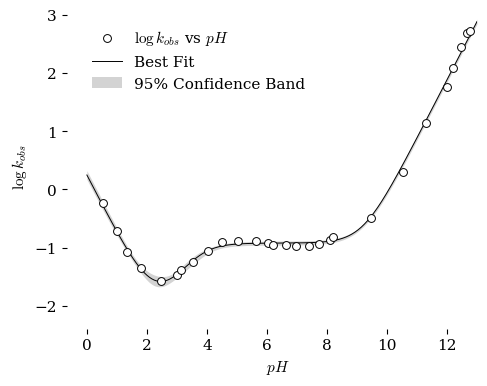

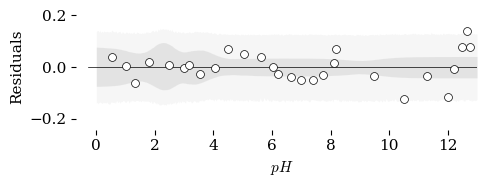

In [15]:
###############################################################################
# Plot
###############################################################################

################################################################################
### Setup a figure  and choose a stylesheet   
################################################################################
plt.rcdefaults()
plt.style.use(github_styles_location + "tufte.mplstyle")        
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,4))  

ax.scatter(x, y, 
           marker = "o", s=32, 
           c="white", edgecolor = "black",
           linewidth = 0.7, label=r"$\log{k_{obs}}$ vs $pH$", zorder=4)



ax.plot(
    x_fit,
    y_fit,
    color="black",
    lw=0.7,
    label="Best Fit",
    zorder = 3
)

ax.fill_between(
    x_fit,
    ci_high,
    ci_low,
    linewidth = 0,
    facecolor="lightgray", #darkgray
    edgecolor = "dimgray",
#    facecolor="lightskyblue",
#    edgecolor = "dodgerblue",
#    alpha=0.30,
    label="95% Confidence Band",
    zorder = 2

)
if False:     # Toggle this to True to see the prediction band. It is not very useful for this data set.
    ax.fill_between(
        x_fit,
        pi_lower,
        pi_upper,
    #    ls = "None",
        linewidth = 0,
        facecolor="gainsboro",
        edgecolor = "darkgray",
    #    facecolor="honeydew",
    #    edgecolor = "lightgreen",
    #    alpha=0.30,
        label="95% Prediction Band",
        zorder = 1
    )



ax.spines["left"].set_position(("outward", 8))
ax.spines["bottom"].set_position(("outward", 8))

ax.set(ylabel=r"$\log{k_{obs}}$", 
       xlabel=r"$pH$",
          xlim=[-0.3,13],                  
          ylim=[-2.2,3]
      )


plt.legend()
plt.tight_layout()
fig.savefig("plots/03_plot_LMFit_CI_PI.pdf")   # use this to save the figure in PDF format

plt.show()

###############################################################################
###############################################################################
###############################################################################
###############################################################################
###############################################################################

###############################################################################
# Generate smooth curve
###############################################################################

# Best-fit curve
y_fit = result.eval(pH=x_fit)

derr_upper = ci_high - y_fit
derr_lower = y_fit - ci_low

prediction_upper = pi_upper - y_fit
prediction_lower = y_fit - pi_lower

################################################################################
### Setup a figure  and choose a stylesheet   
################################################################################
plt.rcdefaults()
plt.style.use(github_styles_location + "tufte.mplstyle")        
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,2))  

################################################################################
### Plot the data and the line fit.   
################################################################################

ax.axhline(0, linewidth = 0.5)

ax.scatter(x, y - result.eval(pH=x), 
           marker = "o", s=32, 
           color="white", edgecolor = "black",
           linewidth = 0.5, zorder=3)

################################################################################
### Set labels and scale 
################################################################################
ax.spines["left"].set_position(("outward", 8))
ax.spines["bottom"].set_position(("outward", 8))

ax.set(ylabel=r"Residuals", 
       xlabel=r"$pH$",
          xlim=[-0.3,13],                  
          ylim=[-0.2,0.2]
      )

#ax.margins(x=.07, y=.07, tight=True)  # add 7% empty space around outside of plot area   


# upper and lower bounds of uncertain kobs as float values

################################################################################
### Create Confidence band upper and lower bounds
################################################################################

ax.fill_between(x_fit, -derr_upper, derr_lower, 
                   color="lightgray", alpha=0.5, zorder = 0,
                   linewidth=0, label="confidence interval")

# prediction inteerval bounds
ax.fill_between(x_fit, -prediction_upper, prediction_lower,
                   color="lightgray", alpha=0.20, zorder = 0,
                   linewidth=0, label="prediction interval")

#############################
### Output the final plot ###
#############################

fig.savefig("plots/06_plot_pH3_LMFit_residuals.pdf")   # use this to save the figure in PDF format
plt.show()                 # output the combined plot plots


### Prediction Interval

Successful fits: 5000/5000


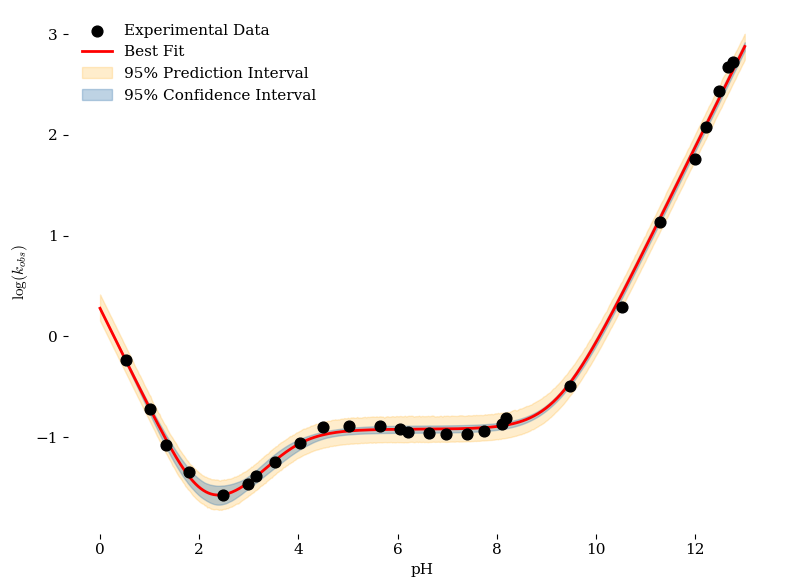

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

###############################################################################
# Bootstrap confidence and prediction bands
###############################################################################

nboot = 5000
seed = 123

rng = np.random.default_rng(seed)

###############################################################################
# Smooth pH grid
###############################################################################


###############################################################################
# Original fitted curve
###############################################################################

y_fit = result.eval(pH=x_fit)

###############################################################################
# Residuals from original fit
###############################################################################

residuals = (result.data - result.best_fit)

###############################################################################
# Storage
###############################################################################

curve_samples = []

successful = 0

###############################################################################
# Residual bootstrap
###############################################################################

for i in range(nboot):

    try:

        resampled_residuals = rng.choice(
            residuals,
            size=len(residuals),
            replace=True
        )

        y_boot = (
            result.best_fit
            + resampled_residuals
        )

        boot = gmodel.fit(
            y_boot,
            result.params.copy(),
            pH=x
        )

        curve = boot.eval(
            pH=x_fit
        )

        curve_samples.append(curve)

        successful += 1

    except Exception:
        pass

curve_samples = np.asarray(
    curve_samples
)

print(
    f"Successful fits: "
    f"{successful}/{nboot}"
)

###############################################################################
# 95% bootstrap confidence band
###############################################################################

ci_lower = np.percentile(
    curve_samples,
    2.5,
    axis=0
)

ci_upper = np.percentile(
    curve_samples,
    97.5,
    axis=0
)

prediction_samples = np.empty_like(
    curve_samples
)

for i in range(curve_samples.shape[0]):

    noise = rng.choice(
        residuals,
        size=len(x_fit),
        replace=True
    )

    prediction_samples[i] = (
        curve_samples[i]
        + noise
    )
###############################################################################
# 95% prediction band
###############################################################################

pi_lower = np.percentile(
    prediction_samples,
    2.5,
    axis=0
)

pi_upper = np.percentile(
    prediction_samples,
    97.5,
    axis=0
)

###############################################################################
# Plot
###############################################################################

plt.figure(figsize=(8, 6))

# Experimental data

plt.scatter(
    x,
    y,
    color="black",
    s=60,
    zorder=10,
    label="Experimental Data"
)

# Best-fit curve

plt.plot(
    x_fit,
    y_fit,
    color="red",
    lw=2,
    label="Best Fit"
)

# Prediction interval (plot first)

plt.fill_between(
    x_fit,
    pi_lower,
    pi_upper,
    color="orange",
    alpha=0.20,
    label="95% Prediction Interval"
)

# Confidence interval

plt.fill_between(
    x_fit,
    ci_lower,
    ci_upper,
    color="steelblue",
    alpha=0.35,
    label="95% Confidence Interval"
)

plt.xlabel("pH")
plt.ylabel(r"$\log(k_{obs})$")

plt.legend()

plt.tight_layout()

plt.show()

[[Model]]
    Model(aspirin_model)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 31
    # data points      = 28
    # variables        = 5
    chi-square         = 0.09112114
    reduced chi-square = 0.00396179
    Akaike info crit   = -150.377559
    Bayesian info crit = -143.716536
    R-squared          = 0.99816138
[[Variables]]
    ka:   1.74957088 +/- 0.17393097 (9.94%) (init = 1.5)
    kb:   0.01423668 +/- 0.00449435 (31.57%) (init = 0.015)
    kc:   0.11987218 +/- 0.00542973 (4.53%) (init = 0.15)
    kd:   7555.77817 +/- 405.070508 (5.36%) (init = 10000)
    pKa:  3.65409468 +/- 0.12325730 (3.37%) (init = 4)
[[Correlations]] (unreported correlations are < 0.100)
    C(kb, pKa) = +0.7343
    C(ka, kb)  = -0.5294
    C(kc, pKa) = +0.3992
    C(ka, pKa) = -0.3539
    C(kb, kc)  = +0.1187


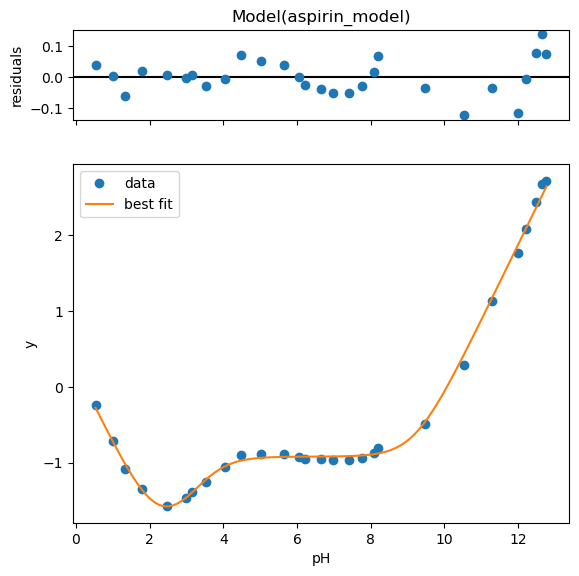

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import lmfit     

plt.rcdefaults()

def aspirin_model(pH, ka , kb, kc, kd, pKa):
    Ka = 10**(-pKa)
    KW = 10**-14   
    H = 10**(-pH)
    k_obs = (ka*(H) + kb + kc*(Ka/H) + kd*(Ka/H)*(KW/H))/(1 + (Ka/H))
    return(np.log10(k_obs))

df = pd.read_csv("data/Edwards1950.csv", 
                 delimiter = ",", 
                 skipinitialspace=True, 
                 index_col="pH", 
                 comment = "#") 
x = df.index
y = np.log10(df["k_obs"])

gmodel = lmfit.Model(aspirin_model, nan_policy='omit')

result = gmodel.fit(y, ka=1.5, kb=0.015, kc=0.15, kd=10000, pKa=4, pH = x)  

print(result.fit_report())
result.plot(numpoints=100)
plt.show()


